# MMLU Cosmic Graph Analysis (Single Precomputed Run)

This notebook loads and analyzes one precomputed cosmic graph output:
- `data/scalability_all_100/mmlu_cosmic_fit_summary.json`
- `data/scalability_all_100/mmlu_cosmic_weighted_adjacency.npz`

It reproduces the key analyses from the original notebook:
1. silhouette sweep across k
2. spectral clustering at best k
3. comparison to subject labels (ARI/NMI)
4. region composition by subject
5. UMAP visualization of graph geometry

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

try:
    import umap
except ImportError as exc:
    raise ImportError("Please install umap-learn: uv pip install umap-learn") from exc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("data")
RUN_DIR = DATA_DIR / "scalability_all_100"
SUMMARY_PATH = RUN_DIR / "mmlu_cosmic_fit_summary.json"
ADJ_PATH = RUN_DIR / "mmlu_cosmic_weighted_adjacency.npz"
MMLU_CACHE = DATA_DIR / "mmlu_questions.csv"

K_RANGE = list(range(2, 21))
RANDOM_STATE = 42
N_INIT = 10
SUBSAMPLE_TARGET = 5000
SUBSAMPLE_SEED = 42

print(f"Summary path: {SUMMARY_PATH}")
print(f"Adjacency path: {ADJ_PATH}")

Summary path: data/scalability_all_100/mmlu_cosmic_fit_summary.json
Adjacency path: data/scalability_all_100/mmlu_cosmic_weighted_adjacency.npz


---
## Step 1: Load the Precomputed Cosmic Graph

In [12]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Missing summary file: {SUMMARY_PATH}")
if not ADJ_PATH.exists():
    raise FileNotFoundError(f"Missing adjacency file: {ADJ_PATH}")

with SUMMARY_PATH.open("r", encoding="utf-8") as f:
    summary = json.load(f)

with np.load(ADJ_PATH) as z:
    if "weighted_adjacency" in z.files:
        W = z["weighted_adjacency"]
    elif len(z.files) == 1:
        W = z[z.files[0]]
    else:
        raise ValueError(f"Unexpected keys in adjacency npz: {z.files}")

W = np.asarray(W, dtype=np.float64)
if W.ndim != 2 or W.shape[0] != W.shape[1]:
    raise ValueError(f"Adjacency must be square; got shape {W.shape}")

W = np.nan_to_num(W, nan=0.0, posinf=0.0, neginf=0.0)
W = 0.5 * (W + W.T)
W = np.clip(W, 0.0, 1.0)
np.fill_diagonal(W, 1.0)

print("Loaded cosmic graph run")
print(f"Created at: {summary.get('created_at')}")
print(f"Representations fused: {summary.get('fit', {}).get('representations_fused')}")
print(f"Total ball maps: {summary.get('fit', {}).get('total_ball_maps')}")
print(f"Resolved threshold: {summary.get('fit', {}).get('resolved_threshold')}")
print(f"Adjacency shape: {W.shape}")

artifacts = summary.get("artifacts", [])
print(f"Artifact count in summary: {len(artifacts)}")
if len(artifacts) > 0:
    print("First 10 artifacts:")
    for a in artifacts[:10]:
        print(" -", a)

Loaded cosmic graph run
Created at: 2026-04-02T11:44:26.567296+00:00
Representations fused: 100
Total ball maps: 10500
Resolved threshold: 0.0
Adjacency shape: (4970, 4970)
Artifact count in summary: 100
First 10 artifacts:
 - BAAI/bge-base-en-v1.5::v01
 - BAAI/bge-base-en-v1.5::v02
 - BAAI/bge-base-en-v1.5::v03
 - BAAI/bge-base-en-v1.5::v04
 - BAAI/bge-base-en-v1.5::v05
 - BAAI/bge-base-en-v1.5::v06
 - BAAI/bge-base-en-v1.5::v07
 - BAAI/bge-base-en-v1.5::v08
 - BAAI/bge-base-en-v1.5::v09
 - BAAI/bge-base-en-v1.5::v10


In [13]:
def build_subsample(df_mmlu: pd.DataFrame, n_subsample: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    indices = []

    for subj in df_mmlu["subject"].unique():
        subj_idx = df_mmlu.index[df_mmlu["subject"] == subj].tolist()
        n_take = max(10, int(n_subsample * len(subj_idx) / len(df_mmlu)))
        n_take = min(n_take, len(subj_idx))
        chosen = rng.choice(subj_idx, size=n_take, replace=False)
        indices.extend(chosen.tolist())

    if len(indices) > n_subsample:
        indices = sorted(rng.choice(indices, size=n_subsample, replace=False))
    else:
        indices = sorted(indices)

    return df_mmlu.iloc[indices].reset_index(drop=True)

if not MMLU_CACHE.exists():
    raise FileNotFoundError(f"Missing dataset cache: {MMLU_CACHE}")

df_mmlu = pd.read_csv(MMLU_CACHE)
df_sub = build_subsample(df_mmlu, n_subsample=SUBSAMPLE_TARGET, seed=SUBSAMPLE_SEED)

subject_codes_full = pd.Categorical(df_mmlu["subject"]).codes
subject_codes_sub = pd.Categorical(df_sub["subject"]).codes

run_rows = int(summary.get("metadata_index", {}).get("rows", W.shape[0]))
run_mode = summary.get("metadata_index", {}).get("run_mode", "subsample")

if run_rows == len(df_sub):
    subject_codes = subject_codes_sub
    analysis_frame = df_sub.copy()
elif run_rows == len(df_mmlu):
    subject_codes = subject_codes_full
    analysis_frame = df_mmlu.copy()
else:
    raise RuntimeError(
        f"Row mismatch: run rows={run_rows}, subsample rows={len(df_sub)}, full rows={len(df_mmlu)}"
    )

if W.shape[0] != len(subject_codes):
    raise RuntimeError(f"Adjacency rows {W.shape[0]} do not match label rows {len(subject_codes)}")

print(f"Run mode: {run_mode}")
print(f"Rows used for analysis: {len(analysis_frame):,}")
print(f"Subjects represented: {analysis_frame['subject'].nunique()}")

Run mode: subsample
Rows used for analysis: 4,970
Subjects represented: 57


In [14]:
dist_matrix = 1.0 - W
np.fill_diagonal(dist_matrix, 0.0)

silhouette_scores = []
labels_by_k = {}

print("Silhouette sweep:")
for k in K_RANGE:
    sc = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        random_state=RANDOM_STATE,
        n_init=N_INIT,
    )
    labels_k = sc.fit_predict(W)
    sil_k = silhouette_score(dist_matrix, labels_k, metric="precomputed")
    silhouette_scores.append(float(sil_k))
    labels_by_k[k] = labels_k
    print(f"  k={k:2d}  silhouette={sil_k:.5f}")

best_idx = int(np.argmax(silhouette_scores))
best_k = K_RANGE[best_idx]
best_score = float(silhouette_scores[best_idx])
labels = labels_by_k[best_k]
analysis_frame["cluster"] = labels

ari_subject = adjusted_rand_score(subject_codes, labels)
nmi_subject = normalized_mutual_info_score(subject_codes, labels)

print("\nBest silhouette result")
print(f"Best k: {best_k}")
print(f"Best silhouette: {best_score:.5f}")
print(f"ARI(subject vs topology): {ari_subject:.4f}")
print(f"NMI(subject vs topology): {nmi_subject:.4f}")

cluster_sizes = np.bincount(labels)
print(f"Cluster sizes: {cluster_sizes.tolist()}")

Silhouette sweep:
  k= 2  silhouette=0.01246
  k= 3  silhouette=0.01255
  k= 4  silhouette=0.01304
  k= 5  silhouette=0.01366
  k= 6  silhouette=0.01387
  k= 7  silhouette=0.01421
  k= 8  silhouette=0.01427
  k= 9  silhouette=0.01466
  k=10  silhouette=0.01491
  k=11  silhouette=0.01487
  k=12  silhouette=0.01501
  k=13  silhouette=0.01567
  k=14  silhouette=0.01613
  k=15  silhouette=0.01627
  k=16  silhouette=0.00893
  k=17  silhouette=0.00907
  k=18  silhouette=0.00921
  k=19  silhouette=0.00946
  k=20  silhouette=0.00961

Best silhouette result
Best k: 15
Best silhouette: 0.01627
ARI(subject vs topology): 0.2079
NMI(subject vs topology): 0.4704
Cluster sizes: [421, 237, 209, 964, 226, 637, 5, 387, 318, 407, 339, 257, 7, 459, 97]


---
## Step 2: Silhouette Curve and Cluster Composition

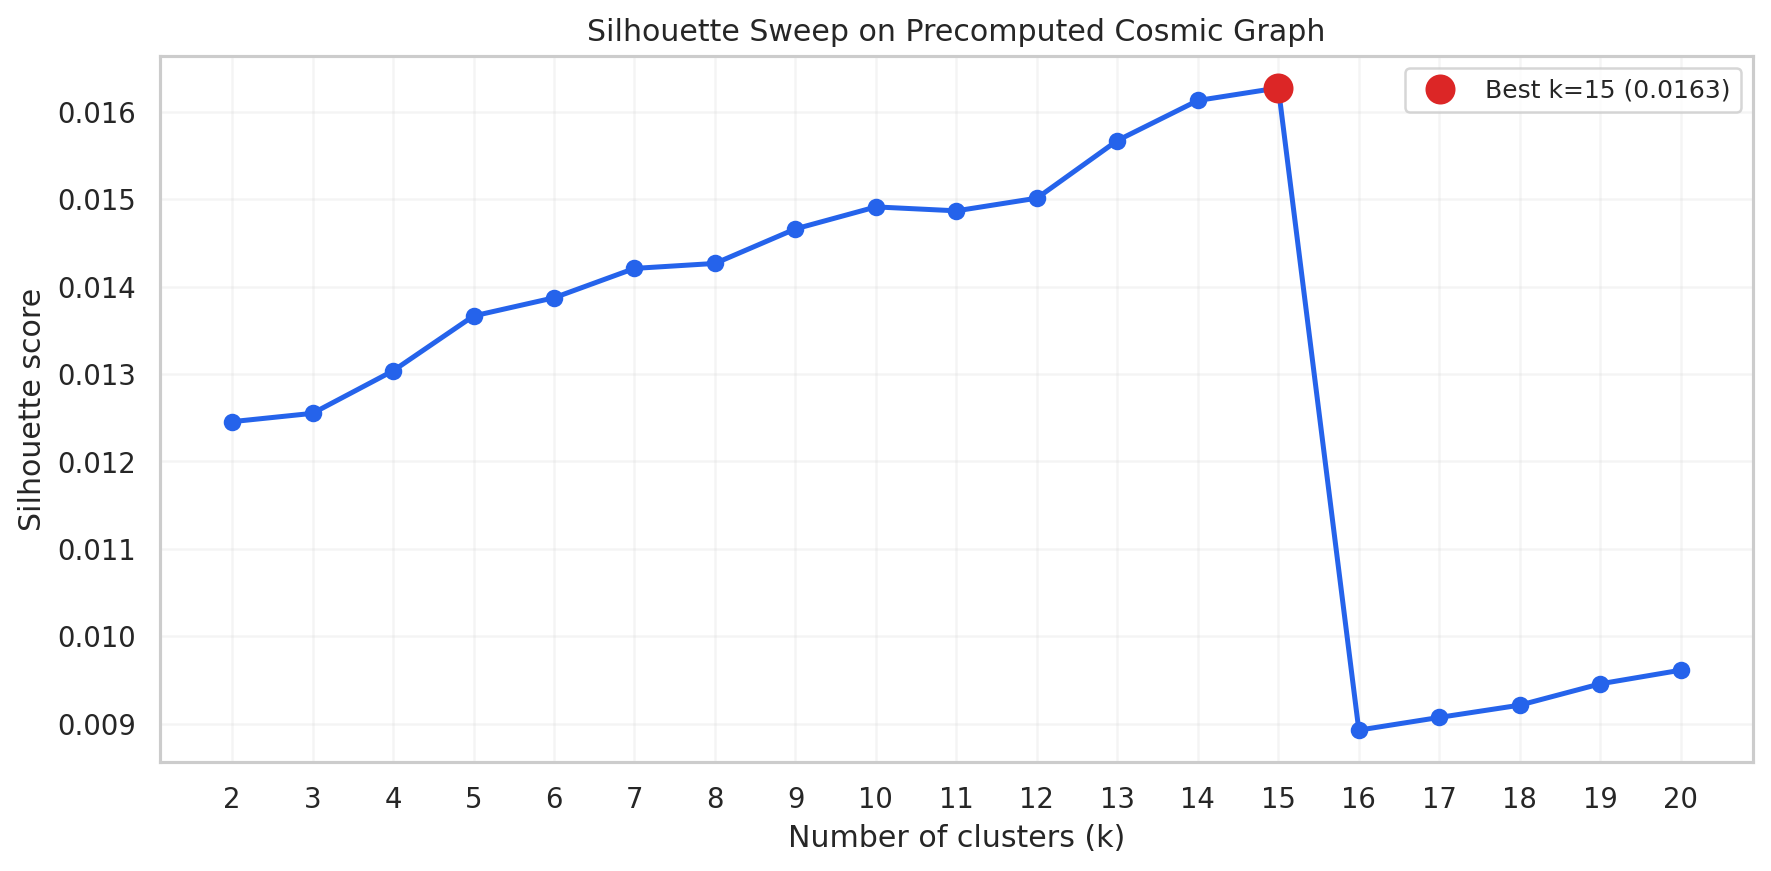

Top 3 subjects per cluster:

Cluster 0 (n=421, subjects=32):
  conceptual_physics: 52 (12.4%)
  high_school_chemistry: 52 (12.4%)
  high_school_physics: 43 (10.2%)

Cluster 1 (n=237, subjects=17):
  elementary_mathematics: 77 (32.5%)
  high_school_mathematics: 69 (29.1%)
  abstract_algebra: 21 (8.9%)

Cluster 2 (n=209, subjects=6):
  high_school_world_history: 80 (38.3%)
  high_school_us_history: 72 (34.4%)
  high_school_european_history: 52 (24.9%)

Cluster 3 (n=964, subjects=51):
  professional_psychology: 156 (16.2%)
  high_school_psychology: 121 (12.6%)
  human_aging: 50 (5.2%)

Cluster 4 (n=226, subjects=2):
  professional_law: 225 (99.6%)
  professional_accounting: 1 (0.4%)

Cluster 5 (n=637, subjects=32):
  moral_disputes: 92 (14.4%)
  philosophy: 88 (13.8%)
  security_studies: 58 (9.1%)

Cluster 6 (n=5, subjects=4):
  high_school_microeconomics: 2 (40.0%)
  college_mathematics: 1 (20.0%)
  college_medicine: 1 (20.0%)

Cluster 7 (n=387, subjects=34):
  miscellaneous: 109 (28.2%)

In [15]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white", dpi=180)
ax.plot(K_RANGE, silhouette_scores, "o-", color="#2563eb", linewidth=2, markersize=6)
ax.plot(best_k, best_score, "o", color="#dc2626", markersize=11, label=f"Best k={best_k} ({best_score:.4f})")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Sweep on Precomputed Cosmic Graph")
ax.set_xticks(K_RANGE)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Top 3 subjects per cluster:")
for c in range(best_k):
    block = analysis_frame[analysis_frame["cluster"] == c]
    top = block["subject"].value_counts().head(3)
    print(f"\nCluster {c} (n={len(block)}, subjects={block['subject'].nunique()}):")
    for subj, count in top.items():
        print(f"  {subj}: {count} ({100.0 * count / len(block):.1f}%)")

---
## Step 3: Topology vs Subject Label Scatter

/home/ec2-user/krv/pulsar/.venv/lib64/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ec2-user/krv/pulsar/.venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


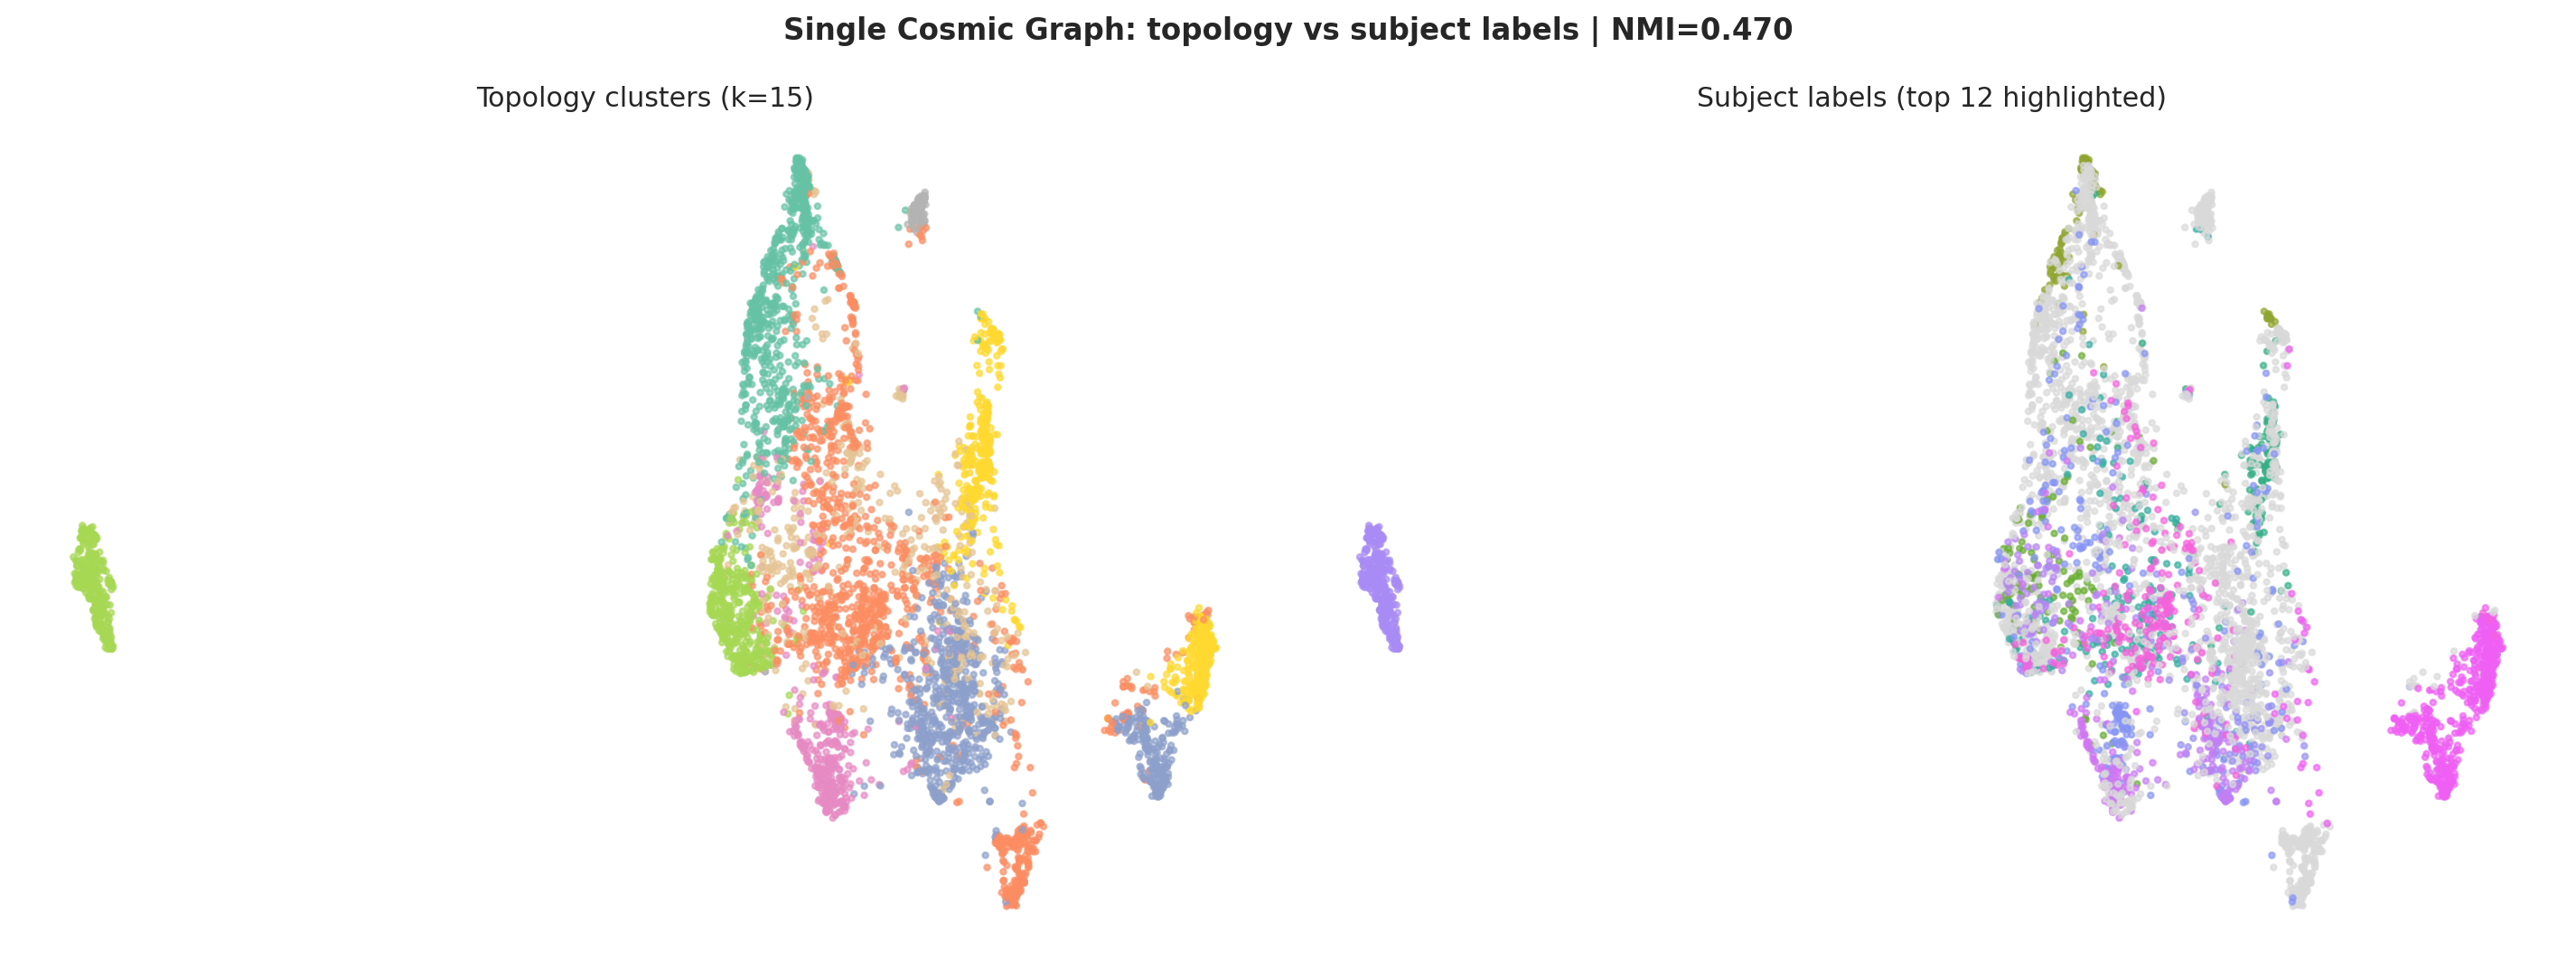

Top 12 highlighted subjects:
 - professional_law
 - moral_scenarios
 - miscellaneous
 - professional_psychology
 - high_school_psychology
 - high_school_macroeconomics
 - elementary_mathematics
 - moral_disputes
 - prehistory
 - high_school_biology
 - philosophy
 - nutrition


In [16]:
# Build a 2D embedding from graph distances for visualization
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="precomputed",
    random_state=RANDOM_STATE,
)
umap_2d = reducer.fit_transform(dist_matrix)

# Colors for topology clusters
cluster_cmap = plt.cm.Set2
cluster_colors = [cluster_cmap(labels[i] / max(best_k, 1)) for i in range(len(labels))]

# Colors for subjects (top 12 highlighted, others gray)
top_subjects = analysis_frame["subject"].value_counts().head(12).index.tolist()
all_subjects = sorted(analysis_frame["subject"].unique())
subject_palette = sns.color_palette("husl", len(all_subjects))
subject_to_color = {s: subject_palette[i] for i, s in enumerate(all_subjects)}
subject_colors = [subject_to_color[s] if s in top_subjects else (0.85, 0.85, 0.85) for s in analysis_frame["subject"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="white", dpi=180)

axes[0].scatter(
    umap_2d[:, 0], umap_2d[:, 1],
    c=cluster_colors, s=6, alpha=0.65, rasterized=True,
 )
axes[0].set_title(f"Topology clusters (k={best_k})")
axes[0].axis("off")

axes[1].scatter(
    umap_2d[:, 0], umap_2d[:, 1],
    c=subject_colors, s=6, alpha=0.65, rasterized=True,
 )
axes[1].set_title("Subject labels (top 12 highlighted)")
axes[1].axis("off")

fig.suptitle(
    f"Single Cosmic Graph: topology vs subject labels | NMI={nmi_subject:.3f}",
    fontsize=13,
    fontweight="bold",
 )
plt.tight_layout()
plt.show()

print("Top 12 highlighted subjects:")
for s in top_subjects:
    print(" -", s)

---
## Step 4: Save Analysis Outputs

In [17]:
OUT_DIR = DATA_DIR / "multiverse_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_payload = {
    "summary_path": str(SUMMARY_PATH),
    "adjacency_path": str(ADJ_PATH),
    "rows": int(len(analysis_frame)),
    "best_k": int(best_k),
    "best_silhouette": float(best_score),
    "ari_subject": float(ari_subject),
    "nmi_subject": float(nmi_subject),
    "cluster_sizes": cluster_sizes.tolist(),
}

metrics_json = OUT_DIR / "single_run_metrics.json"
with metrics_json.open("w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

analysis_frame[["subject", "cluster"]].to_csv(OUT_DIR / "single_run_subject_cluster.csv", index=False)
np.save(OUT_DIR / "single_run_umap_2d.npy", umap_2d)

print("Saved outputs:")
print(f" - {metrics_json}")
print(f" - {OUT_DIR / 'single_run_subject_cluster.csv'}")
print(f" - {OUT_DIR / 'single_run_umap_2d.npy'}")

Saved outputs:
 - data/multiverse_analysis/single_run_metrics.json
 - data/multiverse_analysis/single_run_subject_cluster.csv
 - data/multiverse_analysis/single_run_umap_2d.npy
